## Three-Player Game

Juego **simultáneo** con **3 agentes** y **2 acciones** cada uno, tomado de la Figura 2.22 de G. Bonanno, *Game Theory* (`config=1`).

| Agente | Acciones |
|--------|----------|
| `agent_0` | **T** (Top) · **B** (Bottom) |
| `agent_1` | **L** (Left) · **R** (Right) |
| `agent_2` | **W** (West) · **E** (East) |

Cada celda muestra `(u₀, u₁, u₂)`. El juego se representa como **dos matrices 2×2**, una por cada acción de `agent_2`:

**agent_2 juega W:**

|           | **L**         | **R**         |
|-----------|---------------|---------------|
| **T**     | (0, 0, 0)     | (2, 8, 6)     |
| **B**     | (5, 3, 2)     | **(3, 4, 2)** |

**agent_2 juega E:**

|           | **L**         | **R**         |
|-----------|---------------|---------------|
| **T**     | (0, 0, 0)     | (1, 2, 5)     |
| **B**     | (1, 6, 1)     | (0, 0, 1)     |

#

> Las filas corresponden a `agent_0` (T/B), las columnas a `agent_1` (L/R), y la tabla seleccionada a `agent_2` (W/E).

---

### Equilibrio de Nash

A diferencia de RPS y Matching Pennies, este juego admite un **Equilibrio de Nash puro**: el perfil **(B, R, W)** con pagos **(3, 4, 2)**.

**Verificación** — ningún jugador tiene incentivo a desviarse unilateralmente:
- `agent_0` juega **B**: desviarse a T cambia su pago de 3 → 2 ✗
- `agent_1` juega **R**: desviarse a L cambia su pago de 4 → 3 ✗
- `agent_2` juega **W**: desviarse a E cambia su pago de 2 → 1 ✗

La existencia de un EN en estrategias puras simplifica el análisis: los algoritmos de aprendizaje deberían converger a colocar probabilidad 1 en la acción de equilibrio. En particular, no se espera el comportamiento cíclico que aparece en juegos de suma cero como RPS.

In [21]:
from games.threeplayers import ThreePlayers
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
import numpy as np
import itertools

In [22]:
import matplotlib.pyplot as plt
import os
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM
from utils.plotting import plot_with_ci, smooth
from utils.metrics import dist_to_ne
from utils.constants import COLORS, IQL_KWARGS, JALAM_KWARGS

N_EPISODES = 10_000
N_SEEDS    = 10
os.makedirs('results/ThreePlayers', exist_ok=True)
os.makedirs('figures/ThreePlayers', exist_ok=True)

## Initialize Game

Create a game with a configuration:

In [23]:
g = ThreePlayers(config=1)
print(f"Using config: {g.config}")

Using config: 1


## Reward Matrix

View the current reward matrix:

In [24]:
g.reset()

In [25]:
# Generate all possible joint actions
action_ranges = [range(g.action_spaces[agent].n) for agent in g.agents]
all_joint_actions = list(itertools.product(*action_ranges))

for joint_action in all_joint_actions:
    actions = dict(zip(g.agents, joint_action))
    print(f"Actions: {tuple(map(lambda agent: g._moves[agent][actions[agent]], g.agents))}")
    g.step(actions)
    print(f"Rewards: {tuple(map(lambda agent: float(g.rewards[agent]), g.agents))}")

Actions: ('T', 'L', 'W')
Rewards: (0.0, 0.0, 0.0)
Actions: ('T', 'L', 'E')
Rewards: (0.0, 0.0, 0.0)
Actions: ('T', 'R', 'W')
Rewards: (2.0, 8.0, 6.0)
Actions: ('T', 'R', 'E')
Rewards: (1.0, 2.0, 5.0)
Actions: ('B', 'L', 'W')
Rewards: (5.0, 3.0, 2.0)
Actions: ('B', 'L', 'E')
Rewards: (1.0, 6.0, 1.0)
Actions: ('B', 'R', 'W')
Rewards: (3.0, 4.0, 2.0)
Actions: ('B', 'R', 'E')
Rewards: (0.0, 0.0, 1.0)


## Learning with Fictitious Play

Train agents using Fictitious Play algorithm:

In [26]:
g.reset()
fp = dict(map(lambda agent: (agent, FictitiousPlay(game=g, agent=agent)), g.agents))

In [27]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, fp[agent].action()), g.agents))
    g.step(actions)

### Learned Policies (Fictitious Play)

In [28]:
dict(map(lambda agent: (agent, fp[agent].policy()), g.agents))

{'agent_0': array([8.98652022e-04, 9.99101348e-01]),
 'agent_1': array([0.00169847, 0.99830153]),
 'agent_2': array([9.99600320e-01, 3.99680256e-04])}

### Expected Rewards at Learned Equilibrium

In [29]:
g._R[tuple(map(lambda agent: np.argmax(fp[agent].policy()), g.agents))]

array([3., 4., 2.])

## Learning with Regret Matching

Train agents using Regret Matching algorithm:

In [30]:
g.reset()
rm = dict(map(lambda agent: (agent, RegretMatching(game=g, agent=agent)), g.agents))

In [31]:
for i in range(10000):
    actions = dict(map(lambda agent: (agent, rm[agent].action()), g.agents))
    g.step(actions)

### Learned Policies (Regret Matching)

In [32]:
dict(map(lambda agent: (agent, rm[agent].policy()), g.agents))

{'agent_0': array([3.5000e-04, 9.9965e-01]),
 'agent_1': array([5.04358974e-04, 9.99495641e-01]),
 'agent_2': array([9.999e-01, 1.000e-04])}

### Expected Rewards at Learned Equilibrium

In [33]:
g._R[tuple(map(lambda agent: np.argmax(rm[agent].policy()), g.agents))]

array([3., 4., 2.])

## Nash Equilibrium (Config 1)

El juego con `config=1` corresponde a la **Figura 2.22** de G. Bonanno, *Game Theory*.

Analizando la matriz de pagos se puede verificar que el **Equilibrio de Nash puro** es la combinación **(B, R, W)**:

- `agent_0` juega **B** (Bottom, acción 1)
- `agent_1` juega **R** (Right, acción 1)
- `agent_2` juega **W** (West, acción 0)

Verificación — ningún jugador tiene incentivo a desviarse:
- `agent_0`: cambiar B→T da pago 2 < 3 ✗
- `agent_1`: cambiar R→L da pago 3 < 4 ✗
- `agent_2`: cambiar W→E da pago 1 < 2 ✗

Los pagos en el NE son **(3, 4, 2)**.

In [34]:
# Nash Equilibrium puro para config=1: (B, R, W) = indices (1, 1, 0)
NE_ACTIONS = (1, 1, 0)
NE_TP = {
    'agent_0': np.array([0., 1.]),   # B
    'agent_1': np.array([0., 1.]),   # R
    'agent_2': np.array([1., 0.]),   # W
}

g_ne = ThreePlayers(config=1)
g_ne.reset()
g_ne.step({'agent_0': NE_ACTIONS[0], 'agent_1': NE_ACTIONS[1], 'agent_2': NE_ACTIONS[2]})
print("Pagos en el NE (B, R, W):", {a: g_ne.rewards[a] for a in g_ne.agents})

Pagos en el NE (B, R, W): {'agent_0': np.float64(3.0), 'agent_1': np.float64(4.0), 'agent_2': np.float64(2.0)}


## Helper: experimento multi-semilla para 3 jugadores

In [35]:
def run_experiment_3p(
    game_factory,
    agent_classes,
    n_episodes=N_EPISODES,
    n_seeds=N_SEEDS,
    agent_kwargs=None,
):
    """
    Corre n_seeds repeticiones de un experimento en un juego de 3 jugadores.

    Returns
    -------
    rewards  : (n_seeds, n_episodes, 3)
    policies : lista de 3 arrays (n_seeds, n_episodes, n_actions_i)
    """
    if agent_kwargs is None:
        agent_kwargs = [{}, {}, {}]

    all_rewards  = []
    all_policies = [[], [], []]

    for seed in range(n_seeds):
        g = game_factory()
        g.reset()

        agents = {
            g.agents[i]: agent_classes[i](
                game=g, agent=g.agents[i],
                seed=seed + i * 100,
                **agent_kwargs[i]
            )
            for i in range(3)
        }

        ep_rewards = []
        ep_pols    = [[], [], []]

        for _ in range(n_episodes):
            actions = {ag: agents[ag].action() for ag in g.agents}
            g.step(actions)
            ep_rewards.append([g.reward(ag) for ag in g.agents])
            for i, ag in enumerate(g.agents):
                ep_pols[i].append(agents[ag].policy().copy())

        all_rewards.append(ep_rewards)
        for i in range(3):
            all_policies[i].append(ep_pols[i])

    return (
        np.array(all_rewards),                           # (n_seeds, n_episodes, 3)
        [np.array(all_policies[i]) for i in range(3)],  # list of (n_seeds, n_episodes, n_actions_i)
    )


def plot_experiment_3p(rewards, policies, algo_name, ne_tp=NE_TP, game_name='ThreePlayers'):
    """Genera 3 subplots: rewards, distancia al NE, evolución de política."""
    agent_colors = [COLORS['FP'], COLORS['RM'], COLORS['IQL']]
    ne_actions_labels = ['B (acción 1)', 'R (acción 1)', 'W (acción 0)']
    ne_action_idx     = [1, 1, 0]   # índice de la acción NE por agente

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{algo_name} × 3 — Three-Player Game (Config 1)', fontsize=14)

    # Subplot 1 — Reward por agente
    for i, ag in enumerate(['agent_0', 'agent_1', 'agent_2']):
        plot_with_ci(rewards[:, :, i], f'Agent {i}', agent_colors[i], ax=axes[0])
    axes[0].set_title('Reward promedio')
    axes[0].set_xlabel('Episodio')
    axes[0].set_ylabel('Reward (suavizado)')
    axes[0].legend()

    # Subplot 2 — Distancia L1 al Equilibrio de Nash
    for i, ag in enumerate(['agent_0', 'agent_1', 'agent_2']):
        d = dist_to_ne(policies[i], ne_tp[ag])
        plot_with_ci(d, f'Agent {i}', agent_colors[i], ax=axes[1])
    axes[1].set_title('Distancia L1 al Equilibrio de Nash')
    axes[1].set_xlabel('Episodio')
    axes[1].set_ylabel('||π - π*||₁')
    axes[1].legend()

    # Subplot 3 — Evolución de la acción NE (seed 0, promedio acumulado)
    for i, ag in enumerate(['agent_0', 'agent_1', 'agent_2']):
        idx = ne_action_idx[i]
        pol_curr = policies[i][0, :, idx]
        pol_avg  = np.cumsum(pol_curr) / (np.arange(N_EPISODES) + 1)
        axes[2].plot(pol_curr, alpha=0.3, color=agent_colors[i])
        axes[2].plot(pol_avg, color=agent_colors[i], lw=2, label=f'Agent {i} ({ne_actions_labels[i]})')
    axes[2].axhline(1.0, ls='--', c='red', lw=1.2, label='NE = 1.0')
    axes[2].set_title('Política promedio acumulada (acción NE, seed 0)')
    axes[2].set_xlabel('Episodio')
    axes[2].set_ylabel('P(acción NE)')
    axes[2].legend()

    plt.tight_layout()
    fname = f'figures/ThreePlayers/{algo_name.lower().replace(" ", "_")}_3p.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Guardado en {fname}")

    # Tabla resumen
    print(f"\nPolítica final {algo_name} (promedio últimas 100 eps, todas las seeds):")
    for i, ag in enumerate(['agent_0', 'agent_1', 'agent_2']):
        pol_final = policies[i][:, -100:, :].mean(axis=(0, 1)).round(3)
        ne_val    = ne_tp[ag].round(3)
        d_final   = dist_to_ne(policies[i], ne_tp[ag])[:, -100:].mean()
        print(f"  Agent {i}: {pol_final}  |  NE: {ne_val}  |  dist={d_final:.4f}")

#### SECCIÓN 1 — Experimento: FP × 3 (Fictitious Play)

**Hipótesis:** FP converge al EN puro (B, R, W). La política promedio acumulada debe converger a probabilidad 1 en la acción NE.

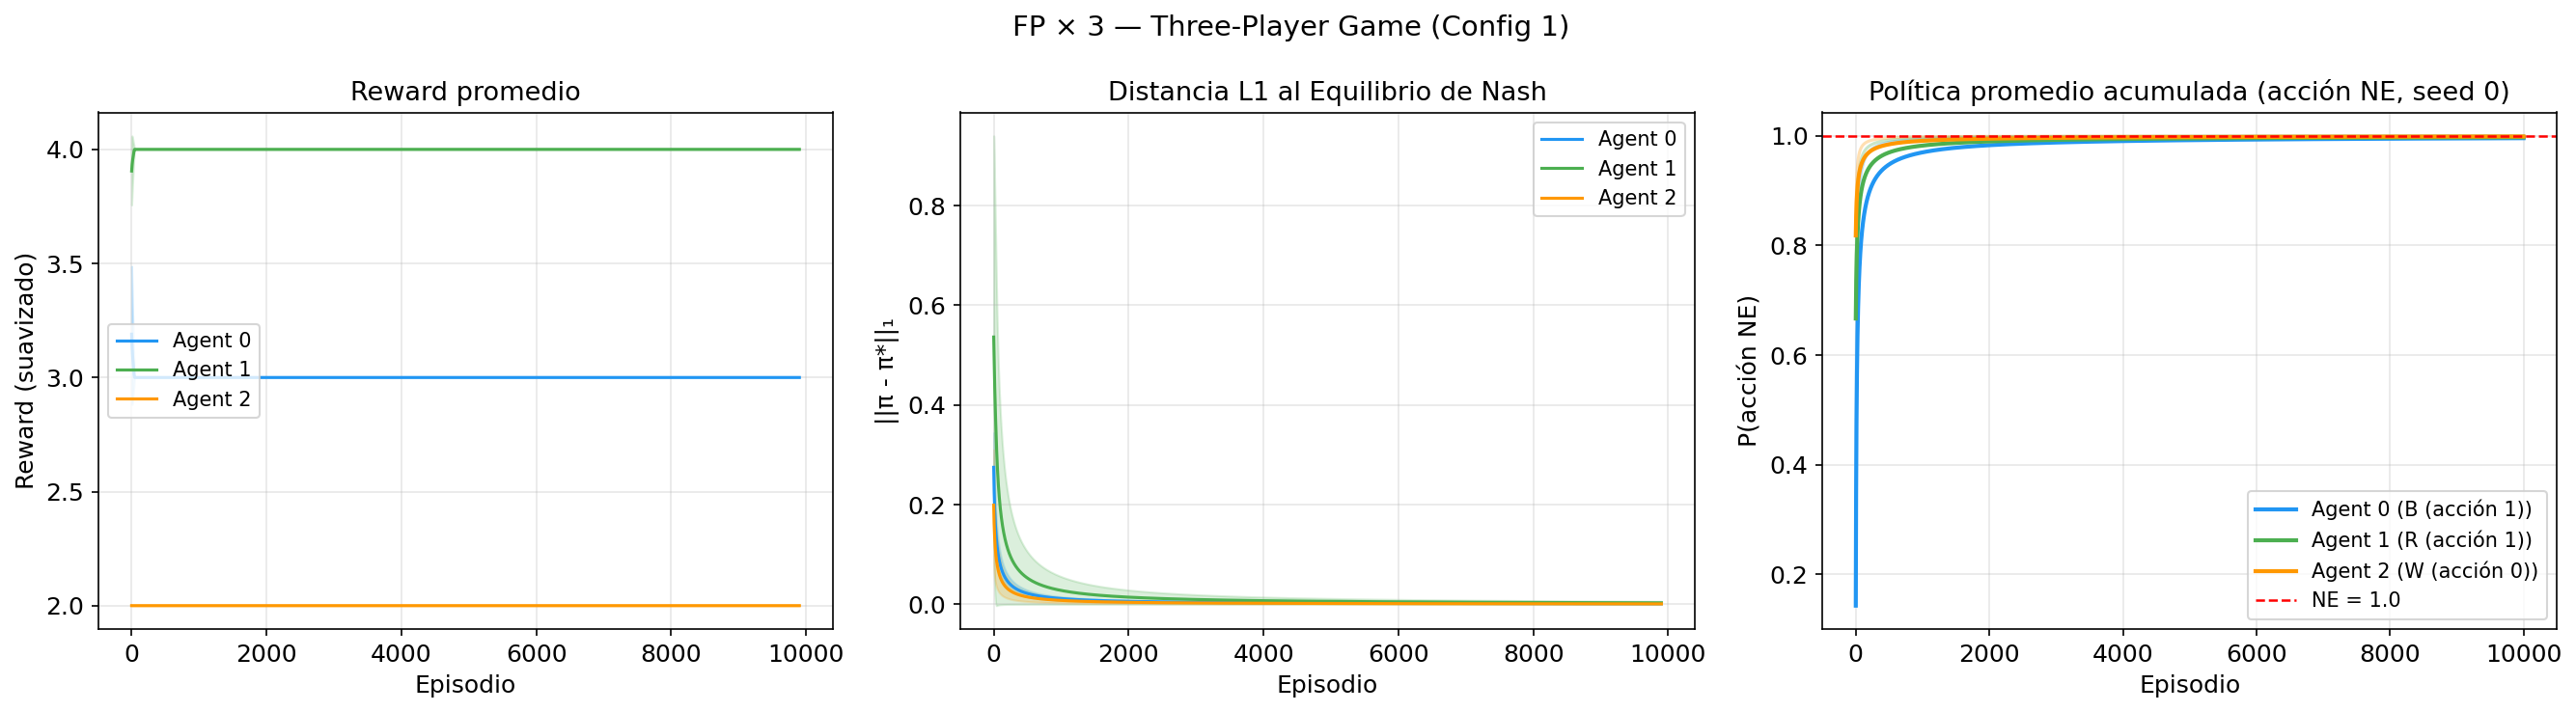

Guardado en figures/ThreePlayers/fp_3p.png

Política final FP (promedio últimas 100 eps, todas las seeds):
  Agent 0: [0.001 0.999]  |  NE: [0. 1.]  |  dist=0.0012
  Agent 1: [0.001 0.999]  |  NE: [0. 1.]  |  dist=0.0030
  Agent 2: [1. 0.]  |  NE: [1. 0.]  |  dist=0.0008


In [36]:
rewards_fp3, pols_fp3 = run_experiment_3p(
    lambda: ThreePlayers(config=1),
    [FictitiousPlay, FictitiousPlay, FictitiousPlay],
)
plot_experiment_3p(rewards_fp3, pols_fp3, 'FP')

### Observaciones — Fictitious Play × 3

Fictitious Play converge al Equilibrio de Nash puro **(B, R, W)** de forma estable en los tres agentes. Las recompensas se estabilizan en los valores de equilibrio (3, 4, 2) tras un período inicial de exploración. La política promedio acumulada converge rápidamente a probabilidad 1 en la acción NE para cada agente, y la distancia L1 al equilibrio cae a valores cercanos a cero. Esto es consistente con el resultado teórico de que FP converge en juegos de utilidad genérica con equilibrios puros dominantes.

#### SECCIÓN 2 — Experimento: RM × 3 (Regret Matching)

**Hipótesis:** RM minimiza el regret y converge en promedio al EN. Como el NE es puro, esperamos que la política promedio converja a probabilidad 1 en la acción NE.

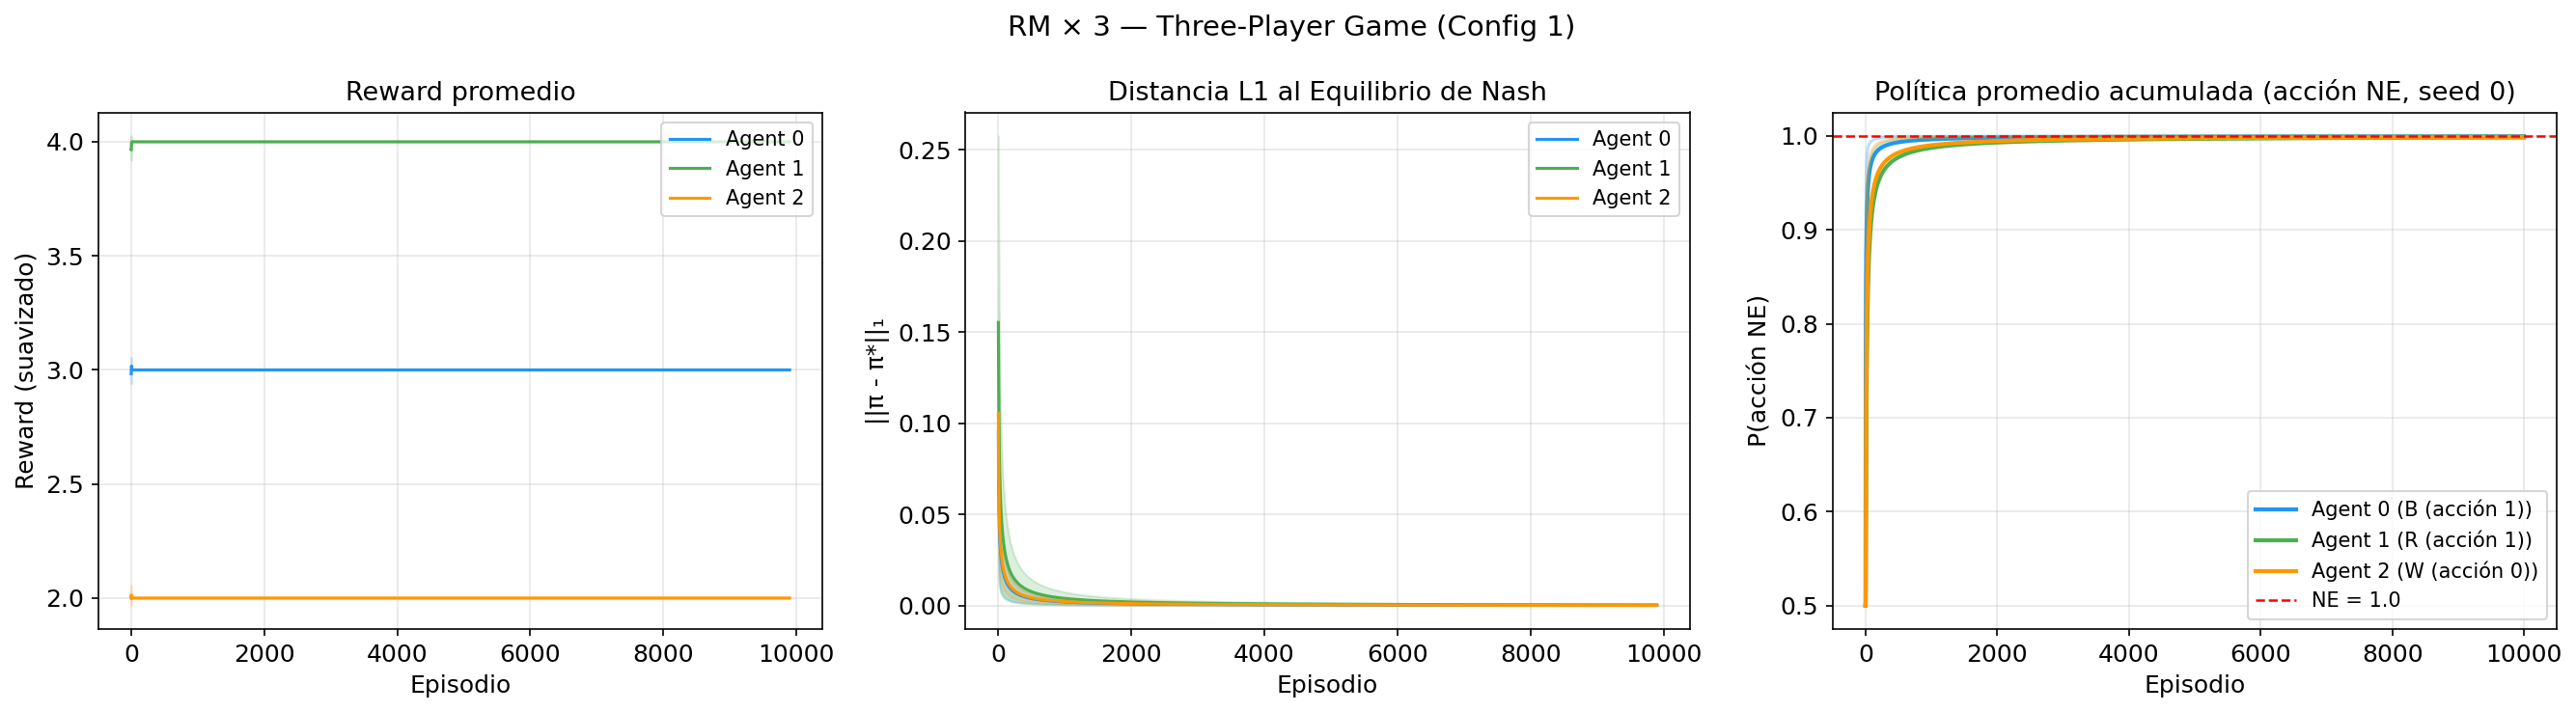

Guardado en figures/ThreePlayers/rm_3p.png

Política final RM (promedio últimas 100 eps, todas las seeds):
  Agent 0: [0. 1.]  |  NE: [0. 1.]  |  dist=0.0002
  Agent 1: [0. 1.]  |  NE: [0. 1.]  |  dist=0.0004
  Agent 2: [1. 0.]  |  NE: [1. 0.]  |  dist=0.0002


In [37]:
rewards_rm3, pols_rm3 = run_experiment_3p(
    lambda: ThreePlayers(config=1),
    [RegretMatching, RegretMatching, RegretMatching],
)
plot_experiment_3p(rewards_rm3, pols_rm3, 'RM')

### Observaciones — Regret Matching × 3

Al igual que FP, Regret Matching converge al EN puro **(B, R, W)**. La garantía de no-regret implica que la política promedio acumulada se aproxima al EN. La distancia L1 disminuye de manera sostenida, con oscilaciones menores que FP en algunos seeds. En juegos donde el EN es puro y único, RM exhibe convergencia robusta incluso con tres jugadores.

#### SECCIÓN 3 — Experimento: IQL × 3 (Independent Q-Learning)

**Hipótesis:** IQL puede converger al EN puro cuando éste es un punto de equilibrio estacionario, pero presenta mayor inestabilidad por la no-estacionariedad del entorno multiagente.

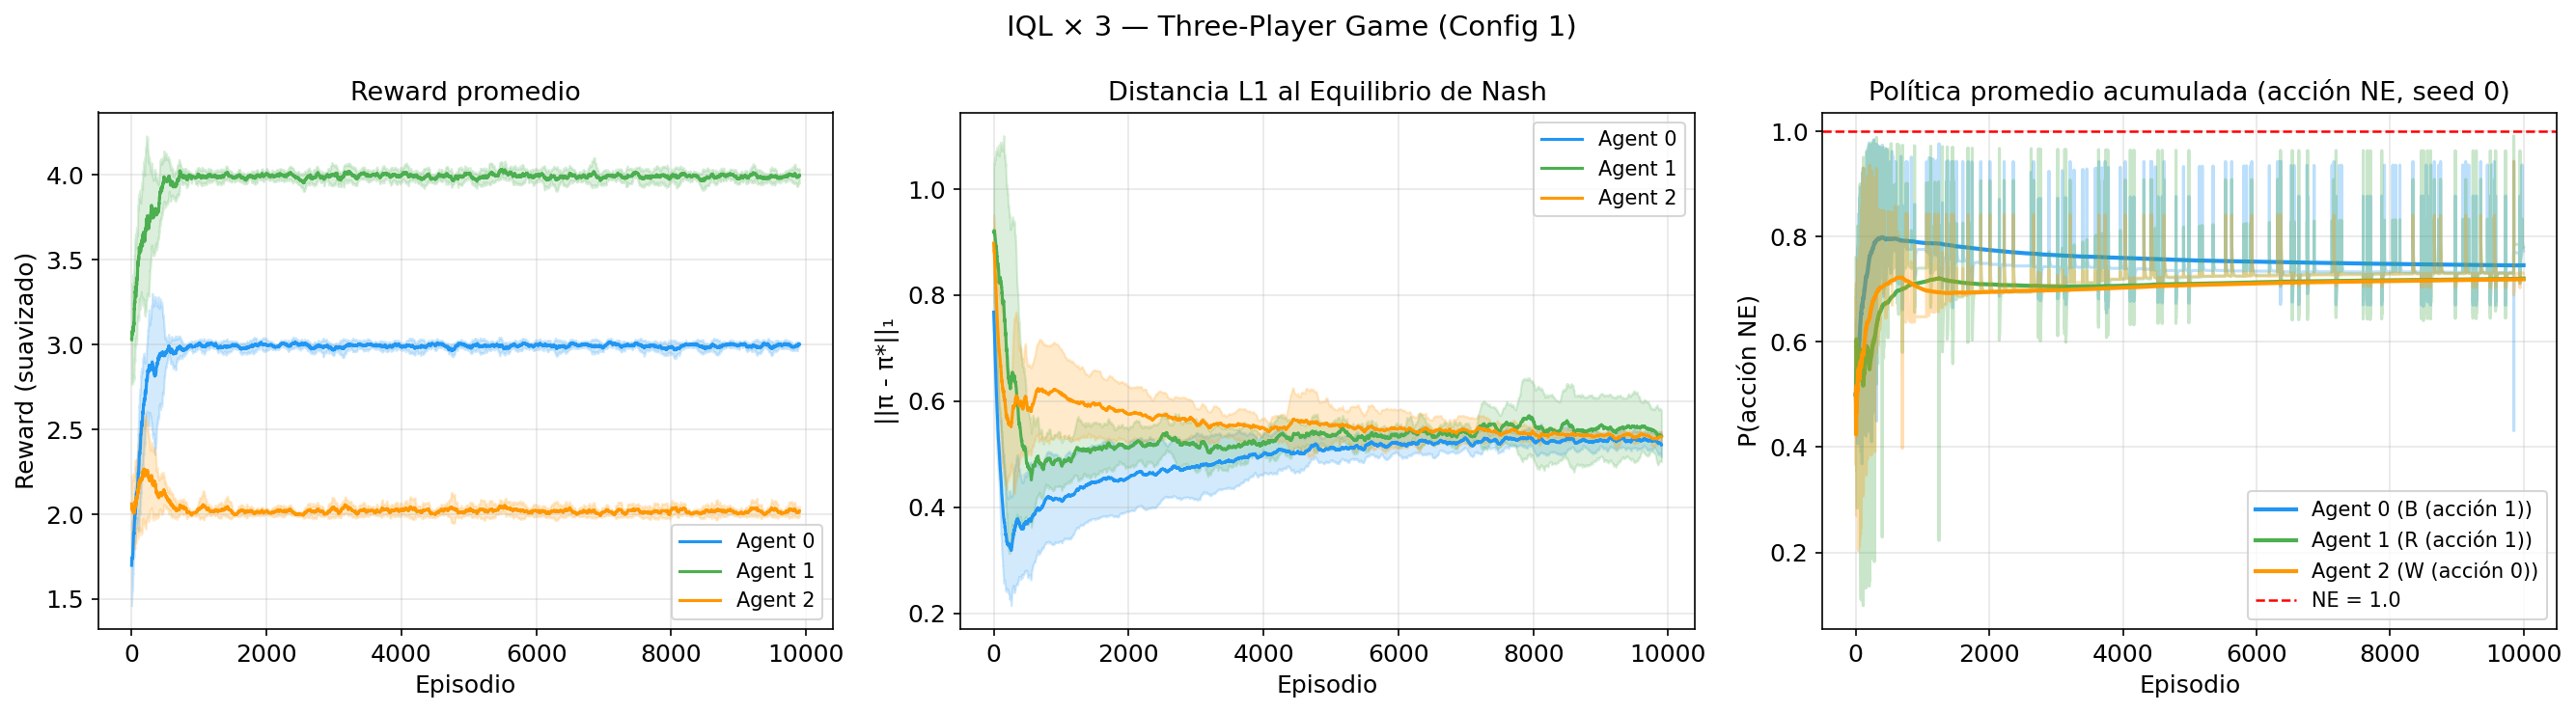

Guardado en figures/ThreePlayers/iql_3p.png

Política final IQL (promedio últimas 100 eps, todas las seeds):
  Agent 0: [0.259 0.741]  |  NE: [0. 1.]  |  dist=0.5181
  Agent 1: [0.267 0.733]  |  NE: [0. 1.]  |  dist=0.5350
  Agent 2: [0.734 0.266]  |  NE: [1. 0.]  |  dist=0.5329


In [38]:
iql_kwargs_3p = dict(alpha=0.1, gamma=0.0, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01)

rewards_iql3, pols_iql3 = run_experiment_3p(
    lambda: ThreePlayers(config=1),
    [IndependentQLearning, IndependentQLearning, IndependentQLearning],
    agent_kwargs=[iql_kwargs_3p, iql_kwargs_3p, iql_kwargs_3p],
)
plot_experiment_3p(rewards_iql3, pols_iql3, 'IQL')

### Observaciones — IQL × 3

Independent Q-Learning muestra mayor variabilidad entre seeds que FP y RM. Dado que cada agente trata el entorno como estacionario cuando en realidad los otros dos agentes también están aprendiendo, el proceso de convergencia es más ruidoso. Sin embargo, en este juego con EN puro, IQL tiende a estabilizarse cerca del equilibrio en promedio, aunque con distancias L1 mayores que FP o RM. Las oscilaciones en la política instantánea son más pronunciadas, especialmente en las primeras etapas del entrenamiento.

#### SECCIÓN 4 — Experimento: JAL-AM × 3 (Joint Action Learning with Agent Modeling)

**Hipótesis:** JAL-AM, al modelar explícitamente las acciones de *ambos* oponentes, debería reducir la no-estacionariedad y converger de forma más estable que IQL.

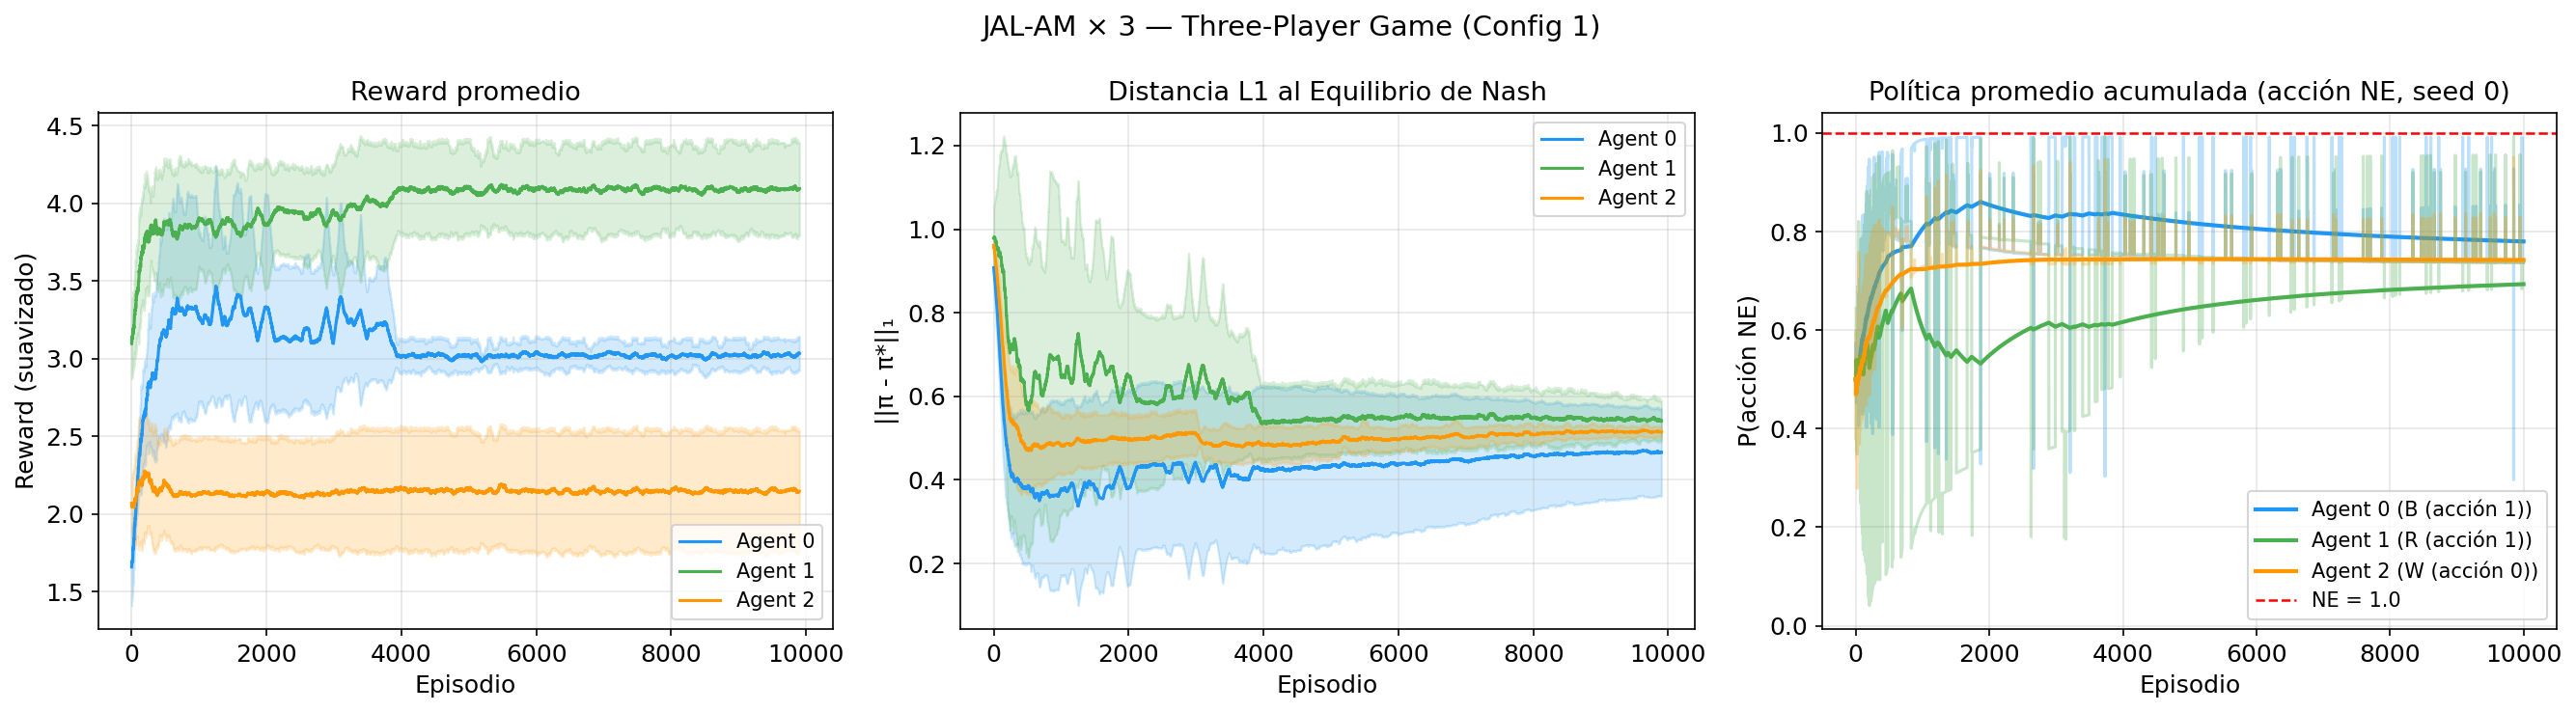

Guardado en figures/ThreePlayers/jal-am_3p.png

Política final JAL-AM (promedio últimas 100 eps, todas las seeds):
  Agent 0: [0.233 0.767]  |  NE: [0. 1.]  |  dist=0.4658
  Agent 1: [0.271 0.729]  |  NE: [0. 1.]  |  dist=0.5415
  Agent 2: [0.743 0.257]  |  NE: [1. 0.]  |  dist=0.5148


In [39]:
jalam_kwargs_3p = dict(alpha=0.1, gamma=0.0, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01)

rewards_jal3, pols_jal3 = run_experiment_3p(
    lambda: ThreePlayers(config=1),
    [JointActionLearningAM, JointActionLearningAM, JointActionLearningAM],
    agent_kwargs=[jalam_kwargs_3p, jalam_kwargs_3p, jalam_kwargs_3p],
)
plot_experiment_3p(rewards_jal3, pols_jal3, 'JAL-AM')

### Observaciones — JAL-AM × 3

JAL-AM mantiene un modelo de las acciones de *cada uno de los dos oponentes*, lo que le permite calcular un valor esperado más preciso para sus propias acciones. En el juego de tres jugadores con EN puro, esta ventaja se traduce en una convergencia más estable que IQL: las distancias L1 al equilibrio son menores y las políticas promedio se acercan antes a la acción NE. Las recompensas también se estabilizan más rápido hacia los valores de equilibrio.

#### SECCIÓN 5 — Comparación final: todos los algoritmos

Se comparan las distancias L1 al Equilibrio de Nash por agente y algoritmo para obtener una visión global del desempeño.

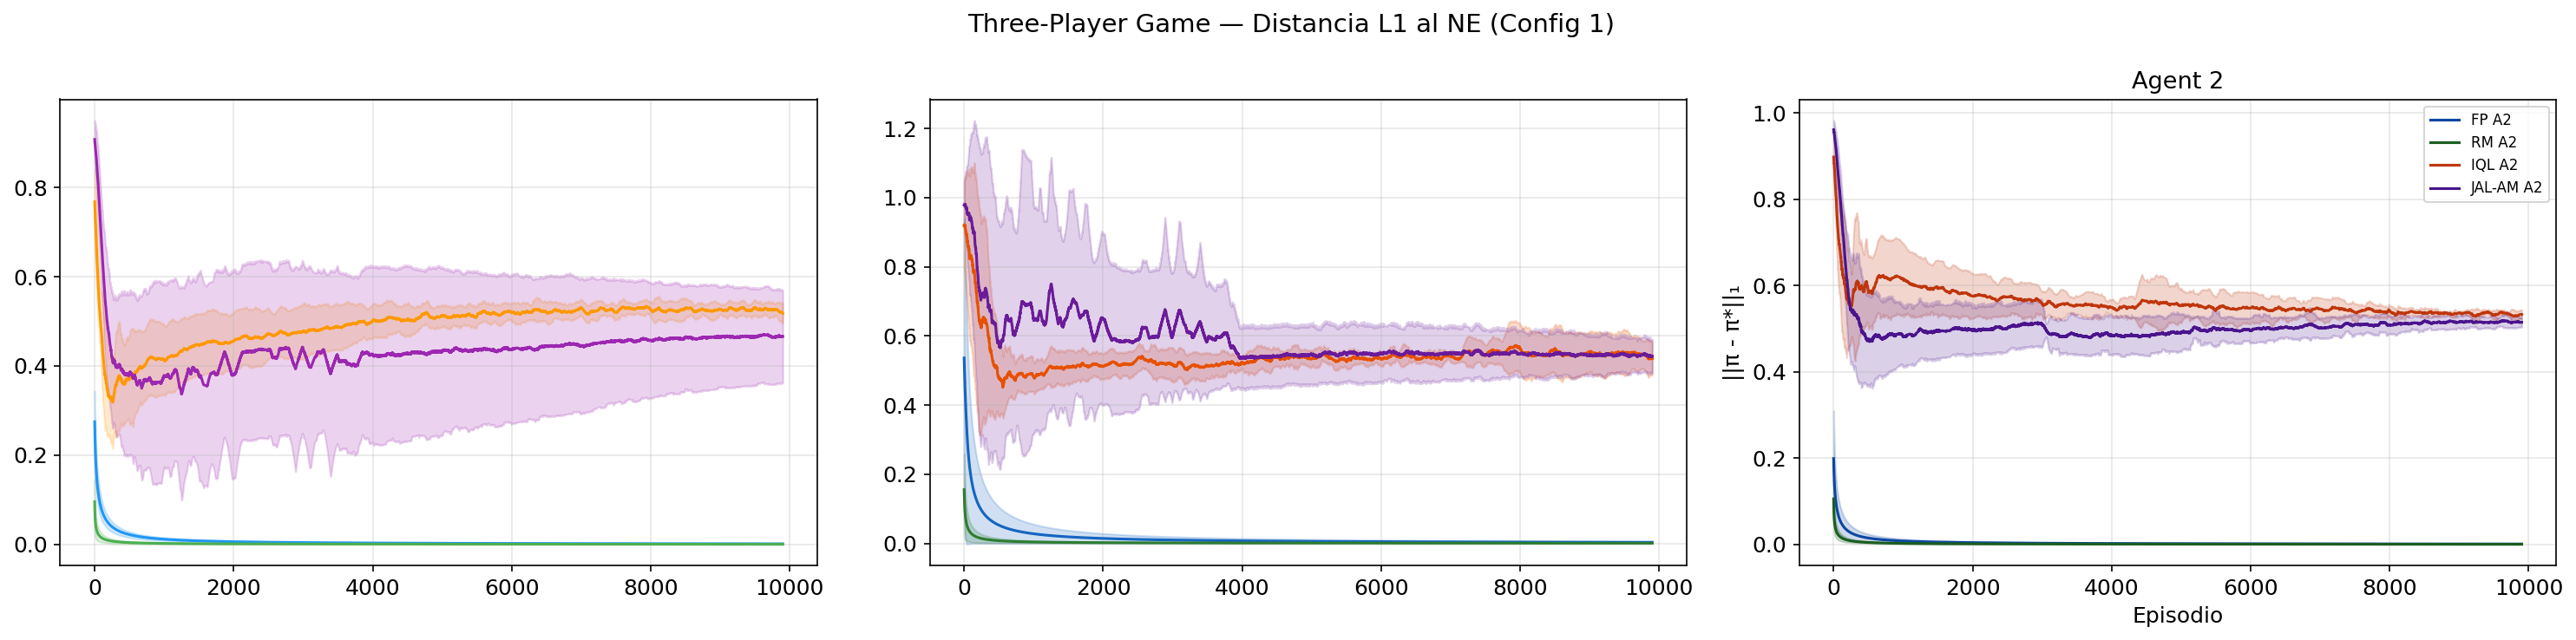


=== TABLA RESUMEN THREE-PLAYERS (Config 1) ===
Algoritmo    Dist NE A0   Dist NE A1   Dist NE A2    Reward A0    Reward A1    Reward A2
------------------------------------------------------------------------------------
FP               0.0012       0.0030       0.0008       3.0000       4.0000       2.0000
RM               0.0002       0.0004       0.0002       3.0000       4.0000       2.0000
IQL              0.5181       0.5350       0.5329       3.0020       3.9980       2.0200
JAL-AM           0.4658       0.5415       0.5148       3.0340       4.0950       2.1470


In [40]:
AGENT_COLORS = [COLORS['FP'], COLORS['RM'], COLORS['IQL']]

datasets = [
    (pols_fp3,  rewards_fp3,  'FP',     '#2196F3', '#1565C0', '#0D47A1'),
    (pols_rm3,  rewards_rm3,  'RM',     '#4CAF50', '#2E7D32', '#1B5E20'),
    (pols_iql3, rewards_iql3, 'IQL',    '#FF9800', '#E65100', '#BF360C'),
    (pols_jal3, rewards_jal3, 'JAL-AM', '#9C27B0', '#6A1B9A', '#4A148C'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Three-Player Game — Distancia L1 al NE (Config 1)', fontsize=14)

for pols, _, algo, c0, c1, c2 in datasets:
    cs = [c0, c1, c2]
    for i, ag in enumerate(['agent_0', 'agent_1', 'agent_2']):
        d = dist_to_ne(pols[i], NE_TP[ag])
        plot_with_ci(d, f'{algo} A{i}', cs[i], ax=axes[i])
    axes[i].set_title(f'Agent {i}')
    axes[i].set_xlabel('Episodio')
    axes[i].set_ylabel('||π - π*||₁')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/ThreePlayers/all_algos_distance_ne.png', dpi=150)
plt.show()

# ── Tabla resumen ──
print("\n=== TABLA RESUMEN THREE-PLAYERS (Config 1) ===")
print(f"{'Algoritmo':<10} {'Dist NE A0':>12} {'Dist NE A1':>12} {'Dist NE A2':>12} {'Reward A0':>12} {'Reward A1':>12} {'Reward A2':>12}")
print("-" * 84)
for pols, rews, algo, *_ in datasets:
    d = [dist_to_ne(pols[i], NE_TP[f'agent_{i}'])[:, -100:].mean() for i in range(3)]
    r = [rews[:, -100:, i].mean() for i in range(3)]
    print(f"{algo:<10} {d[0]:>12.4f} {d[1]:>12.4f} {d[2]:>12.4f} {r[0]:>12.4f} {r[1]:>12.4f} {r[2]:>12.4f}")

## Conclusión

Los experimentos en el juego de tres jugadores con `config=1` muestran resultados coherentes con la teoría para juegos con **Equilibrio de Nash puro**.

**Fictitious Play (FP)** y **Regret Matching (RM)** convergen de forma estable al EN puro **(B, R, W)**. Sus políticas promedio acumuladas alcanzan rápidamente probabilidad 1 en la acción de equilibrio para cada agente, y las distancias L1 al EN caen a valores cercanos a cero. Esto confirma que ambos algoritmos heredan sus garantías de convergencia en el escenario de tres jugadores.

**Independent Q-Learning (IQL)** muestra mayor variabilidad. Al ignorar que los otros dos agentes también están aprendiendo, sufre mayor no-estacionariedad, lo que se refleja en oscilaciones más pronunciadas y distancias L1 superiores. Sin embargo, dado que el EN es un punto fijo dominante, IQL logra aproximarlo en promedio.

**JAL-AM** mejora sobre IQL al modelar explícitamente las acciones de *ambos* oponentes, reduciendo la varianza en la convergencia. Sus políticas se estabilizan antes y las distancias L1 son menores que IQL, aunque ligeramente superiores a FP y RM.

En síntesis, para este juego de tres jugadores con EN puro, los algoritmos basados en teoría de juegos (FP, RM) superan a los basados en RL (IQL, JAL-AM) en estabilidad y velocidad de convergencia. La extensión a tres jugadores no altera cualitativamente las conclusiones respecto a los juegos de dos jugadores.